# CMI and Markov length for GHZ state

Calculating CMI with density matrices 

\begin{equation}

CMI = I(A:C|B) = S(AB) + S(BC) - S(ABC) - S(B),

\end{equation}

where $S(Q)$ is the von Neumann entropy of the $Q$ subsystem:

\begin{equation}

S(Q) = - tr ( \rho_{Q} \log \rho_Q ),

\end{equation}

with

\begin{equation}

\rho_{Q} = tr_{\bar{Q}} (\rho).

\end{equation}

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import math
from functools import reduce
import scienceplots

We will start from defining the GHZ state:

\begin{equation}

\ket{\text{GHZ}}= \frac{1}{\sqrt{2}}(\ket{0}^{\otimes N}+ \ket{1}^{\otimes N})

\end{equation}

and the density matrix:

\begin{equation}

\rho_0 = \ket{\text{GHZ}} \bra{\text{GHZ}}

\end{equation}

In [41]:
# ============================================================
# Defining rho_0
# ============================================================

# -------------------------
# Tensor product helper
# -------------------------
def kron_power(v, N):
    """Compute v ⊗ v ⊗ ... ⊗ v (N times)"""
    return reduce(np.kron, [v] * N)

# -------------------------
# Basis states |0> and |1>
# -------------------------
ket_0 = np.array([1, 0])
ket_1 = np.array([0, 1])


# -------------------------
# Function computing rho_0 given the system size
# -------------------------

def rho_GHZ_function(N):
    """
    Computing rho_GHZ given the system size
    N: total number of qubits
    """

    # Build product states
    # |0...0> and |1...1>
    ket_0N = kron_power(ket_0, N)
    ket_1N = kron_power(ket_1, N)

    # GHZ state
    ket_GHZ = (ket_0N + ket_1N) / np.sqrt(2)
    # Density matrix
    output = np.outer(ket_GHZ, ket_GHZ.conj())
    return output


rho_GHZ = rho_GHZ_function(12)
print(rho_GHZ)
print("Density matrix shape:", rho_GHZ.shape)



[[0.5 0.  0.  ... 0.  0.  0.5]
 [0.  0.  0.  ... 0.  0.  0. ]
 [0.  0.  0.  ... 0.  0.  0. ]
 ...
 [0.  0.  0.  ... 0.  0.  0. ]
 [0.  0.  0.  ... 0.  0.  0. ]
 [0.5 0.  0.  ... 0.  0.  0.5]]
Density matrix shape: (4096, 4096)


Subsequantly, we define the noise channel:

\begin{equation}

\mathcal{E}^i_p(\cdot) = (1-p)(\cdot) + pX_i(\cdot)X_i

\end{equation}

acting on every qubit.

In [ ]:
# ============================================================
# Defining the noise channel
# ============================================================

# -------------------------
# Defining Pauli X matrix 
# -------------------------
Pauli_X= np.array([[0, 1],[1, 0]])

# -------------------------
# Defining identity matrix 
# -------------------------
I = np.eye(2)

# -------------------------
# Defining local operator
# -------------------------
def local_operator(op, i, N):
    """
    Build operator acting on i-th qubit (0-based index) in N-qubit system.
    """
    ops = [I] * N
    ops[i] = op
    return reduce(np.kron, ops)

# -------------------------
# Defining the bit flip channel
# -------------------------
def bit_flip_channel(rho, p, i, N):
    """ 
    Function implementing the application of the noise channel on qubit i. 
    Returns the matrix rho_p_i after the application of the noise on one qubit
    i - qubit number
    p - noise rate 
    N - total system size
    rho - total density matrix
    """
    X_i = local_operator(Pauli_X, i, N)
    return (1 - p) * rho + p * (X_i @ rho @ X_i)

# -------------------------
# Repeated application of bit flip chanell -> noise channel
# -------------------------
def noise_channel(rho_0, p, N):
    """ 
    Function implementing the noise channel on qubit all qubits. 
    Returns the matrix rho_p_i after the application of the noise on one qubit
    i - qubit number
    p - noise rate 
    N - total system size
    rho_0 - initial density matrix
    """
    rho = rho_0
    for i in range(N):
        rho = bit_flip_channel(rho, p, i, N)
    return rho 

Now, we will define functions to caluclate von Neuman entropies of the whole matrix and the reduced density matrices to subsequently calculate CMI. 

In [6]:
# ============================================================
# Functions to compute CMI
# ============================================================

# -------------------------
# Calculating von Neumann entropy
# -------------------------
def von_neumann_entropy(rho):
    """
    Compute von Neumann entropy S(rho) = -Tr(rho log rho) = -Sum (lamba log lamba), 
    where lambda's are eigenvalues of rho
    """
    eigvals = np.linalg.eigvalsh(rho)

    # remove zeros safely
    eigvals = eigvals[eigvals > 1e-12]

    S = -np.sum(eigvals * np.log2(eigvals))

    return S

# -------------------------
# Function to compute reduced density matrix by tracing out subsystems
# -------------------------
def partial_trace(rho, keep, N):
    """
    Partial trace over all qubits not listed in keep.

    rho:
        Full density matrix of shape (2^N, 2^N)

    keep:
        List of qubit indices to keep, using Python 0-based indexing.

    N:
        Total number of qubits.

    Returns:
        Reduced density matrix on the qubits in keep.
    """

    keep = sorted(keep)

    # Qubits to trace out
    trace_out = [q for q in range(N) if q not in keep]

    # Reshape rho into tensor form:
    # rho[i1, i2, ..., iN, j1, j2, ..., jN]
    rho_tensor = rho.reshape([2] * N + [2] * N)

    # Trace out qubits from largest index to smallest.
    # This avoids axis-shifting problems after each trace.
    current_N = N

    for q in sorted(trace_out, reverse=True):
        rho_tensor = np.trace(
            rho_tensor,
            axis1=q,
            axis2=q + current_N,
        )
        current_N -= 1

    dim_keep = 2 ** len(keep)

    return rho_tensor.reshape(dim_keep, dim_keep)

# -------------------------
#Function to compute CMI
# -------------------------
def CMI(p, rho_0, A, B, C, N):
    """
    Compute I(A:C|B) = S(AB) + S(BC) - S(B) - S(ABC).
    """

    rho = noise_channel(rho_0, p, N)

    AB = sorted(A + B)
    BC = sorted(B + C)
    ABC = sorted(A + B + C)

    S_AB = von_neumann_entropy(partial_trace(rho, AB, N))
    S_BC = von_neumann_entropy(partial_trace(rho, BC, N))
    S_B = von_neumann_entropy(partial_trace(rho, B, N))
    S_ABC = von_neumann_entropy(partial_trace(rho, ABC, N))

    return S_AB + S_BC - S_B - S_ABC

The first partition into the regions that we are interested in for 12 qubits is given by:

\begin{align}

&A = [0,1,2,3]\\

&B = [4,5,10,11]\\

&C = [6,7,8,9],

\end{align}

where we considered the indexing of qubits staring from 0 to match the Python syntax. Subsequently, we compute CMI for this region partition.

In [ ]:
# ============================================================
# Computation of CMI
# ============================================================

# -------------------------
# Partition into subregions A,B,C
# -------------------------

A = [0,1,2,3]

B = [4,5,10,11]

C = [6,7,8,9]

# -------------------------
# Computing CMI for different noise rates
# -------------------------

#Array of different noise rates
p_array = np.linspace(0.001,0.999,40)

cmi_array = np.zeros(len(p_array))

for i in range(len(p_array)):
    cmi_array[i] = CMI(p_array[i],rho_GHZ,A=A,B=B,C=C,N=12)

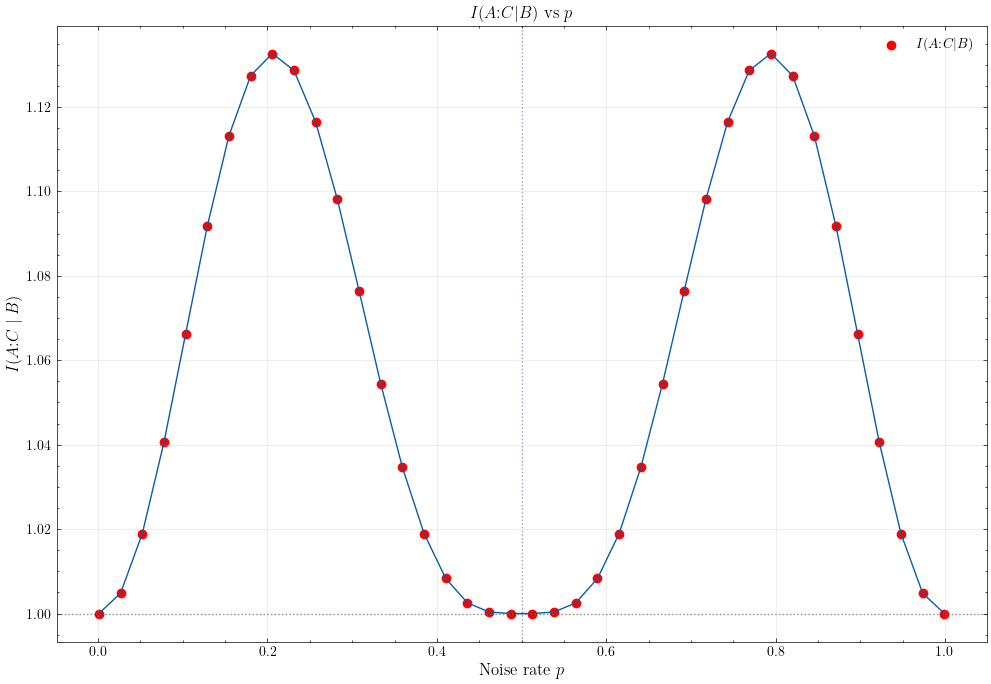

In [23]:
# ============================================================
# Plot of the results of CMI vs noise rate p
# ============================================================


fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(p_array, cmi_array,lw=1)
ax.scatter(p_array, cmi_array,color='red', label=r'$I(A{:}C|B)$')
ax.axhline(1.0, color='black', ls=':', alpha=0.4)
ax.axvline(0.5, color='darkblue', ls=':', alpha=0.4)
ax.set_xlabel(r'Noise rate $p$', fontsize=12)
ax.set_ylabel(r'$I(A{:}C \mid B)$ ', fontsize=12)
ax.set_title(r' $I(A{:}C|B)$ vs $p$', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.annotate(r'$p_c = 0.5$', xy=(0.5, 0.05), fontsize=10, color='blue',
            ha='center', va='bottom')
plt.style.use('science')
plt.show()

The results presented above were computed for 12 qubits, with the partition into regions A,B,C given by: $A = [0,1,2,3], B = [4,5,10,11],$ and $C = [6,7,8,9].$ However, to compute Markov length, we need to repeat the calculation above for different system sizes $r$, where $r$ is the number of qubits separating region A from region C. For instance, for the calculation above, $r=2$, because region $B$ encloses region $A$ like a one-dimensional ring. 

Subsequently, we know that CMI should satisfy the following bound with finite Markov length $\xi = \xi(p)$ as long as the system stays in one-phase of matter:
\begin{equation}
I(A:C \mid B)
\leq a e^{-r/\xi(p)} + c_0,
\end{equation}
where $a$ is a proportionality constant (for constatnt size of regions $A$ and $C$) and $c_0$ is a vertical offset, signifying the minimal value to which the CMI function will be converging for incresing system sizes (which is shown in the following plots). In particular, for GHZ system, $c_0 =1$. 

Then, it is possible to compute $\xi = \xi(p)$ considering:
\begin{equation}
\ln(I(A:C \mid B) - 1) = -\frac{1}{\xi(p)} + \ln{a},
\end{equation}
Therfore, for each noise rate $p$, we can compute CMI for differnt system sizes $r$, and then compute $\xi$ by fitting a linear function to the logarithm of CMI (minus offset) versus $r$, and taking the negative inverse of the slope. This computation was executed below.

In [24]:
#Smaller parameters 
p_array2 = np.linspace(0.001,0.999,10)

In [ ]:
# ============================================================
# Markov length from decay of I(A:C|B) - 1
# ============================================================


def fit_markov_length_direct(distances, cmi_values, threshold=1e-12):
    """
    Fit:

        CMI(r) - 1 = a exp(-r / xi)

    so:

        log(CMI(r)-1) ~ log(a) - r / xi
    """

    distances = np.array(distances)
    cmi_values = np.array(cmi_values)

    mask = cmi_values > threshold

    if np.sum(mask) < 2:
        return np.nan

    x = distances[mask]
    y = np.log(cmi_values[mask] - 1)

    slope, intercept = np.polyfit(x, y, 1)

    if slope >= 0:
        return np.nan

    return -1.0 / slope

# ------------------------------------------------------------
# Define distance-dependent partitions
# ------------------------------------------------------------

LA = 1
LC = 1

# ------------------------------------------------------------
# Define maximum system size
# ------------------------------------------------------------
N2 = 6

distances = np.arange(1, N2 - LA - LC + 1)

cmi_matrix = np.zeros((len(p_array2), len(distances)))

for ip, p in enumerate(p_array2):
    for idd, d in enumerate(distances):

        A_d = list(range(0, LA))
        B_d = list(range(LA, LA + d))
        C_d = list(range(LA + d, LA + d + LC))

        cmi_matrix[ip, idd] = CMI(
            p,
            rho_GHZ,
            A=A_d,
            B=B_d,
            C=C_d,
            N=N
        )

# ------------------------------------------------------------
# Fit Markov length for every p
# ------------------------------------------------------------

xi_array = np.array([
    fit_markov_length_direct(distances, cmi_matrix[ip])
    for ip in range(len(p_array2))
])

print("xi_array:")
print(xi_array)
print("finite xi values:", np.sum(np.isfinite(xi_array)))

xi_array:
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan]
finite xi values: 0


/var/folders/bg/5qsr84rd5gv3r39k5v2x0mm00000gn/T/ipykernel_86451/2055331482.py:26: RuntimeWarning: invalid value encountered in log
  y = np.log(cmi_values[mask] - 1)


In [ ]:
def fit_markov_length_offset(distances, cmi_values, offset=1.0, threshold=1e-12):
    """
    Fit:

        CMI(r) - offset = a exp(-r / xi)

    so:

        log(CMI(r) - offset) = log(a) - r / xi
    """

    distances = np.array(distances)
    cmi_values = np.array(cmi_values)

    shifted = cmi_values - offset

    # Only keep points where log is well-defined
    mask = shifted > threshold

    if np.sum(mask) < 2:
        return np.nan

    x = distances[mask]
    y = np.log(shifted[mask])

    slope, intercept = np.polyfit(x, y, 1)

    if slope >= 0:
        return np.nan

    return -1.0 / slope

# ------------------------------------------------------------
# Define distance-dependent partitions
# ------------------------------------------------------------

LA = 1
LC = 1

# ------------------------------------------------------------
# Define maximum system size
# ------------------------------------------------------------
N = 12

distances = np.arange(1, N - LA - LC + 1)

cmi_matrix = np.zeros((len(p_array2), len(distances)))

for ip, p in enumerate(p_array2):
    for idd, d in enumerate(distances):

        A_d = list(range(0, LA))
        B_d = list(range(LA, LA + d)+ LA, LA + d))
        C_d = list(range(LA + d, LA + d + LC))

        cmi_matrix[ip, idd] = CMI(
            p,
            rho_GHZ,
            A=A_d,
            B=B_d,
            C=C_d,
            N=N
        )

    shifted = cmi_matrix[ip] - 1.0
    print(
        f"p={p:.4f}, "
        f"min CMI={np.min(cmi_matrix[ip]):.6e}, "
        f"max CMI={np.max(cmi_matrix[ip]):.6e}, "
        f"positive shifted points={np.sum(shifted > 1e-12)}"
    )
# ------------------------------------------------------------
# Fit Markov length for every p
# ------------------------------------------------------------



xi_array = np.array([
    fit_markov_length_offset(distances, cmi_matrix[ip], offset=1.0)
    for ip in range(len(p_array2))
])

KeyboardInterrupt: 

In [36]:
xi_array = np.array([
    fit_markov_length_offset(distances, cmi_matrix[ip], offset=1.0)
    for ip in range(len(p_array2))
])

print("xi_array:")
print(xi_array)
print("finite xi values:", np.sum(np.isfinite(xi_array)))

xi_array:
[nan nan nan nan nan nan nan nan nan nan]
finite xi values: 0


In [35]:
# ============================================================
# Plot xi(p) vs p
# ============================================================

valid = np.isfinite(xi_array)

plt.style.use('science')
plt.figure(figsize=(8, 5))

plt.plot(p_array2[valid],xi_array[valid], marker='o',lw=2)

plt.xlabel("Noise rate p")
plt.ylabel("Markov length ξ(p)")
plt.title("Markov Length from Decay of I(A:C|B) - 1")

plt.grid(True)
plt.show()

RuntimeError: latex was not able to process the following string:
b'Markov length \\u03be(p)'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.27 (TeX Live 2025) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./file.tex
LaTeX2e <2024-11-01> patch level 2
L3 programming layer <2025-01-18>
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/article.cls
Document Class: article 2024/06/29 v1.4n Standard LaTeX document class
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/size10.clo))
(/usr/local/texlive/2025/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/local/texlive/2025/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/local/texlive/2025/texmf-dist/tex/latex/geometry/geometry.sty
(/usr/local/texlive/2025/texmf-dist/tex/latex

<Figure size 800x500 with 1 Axes>

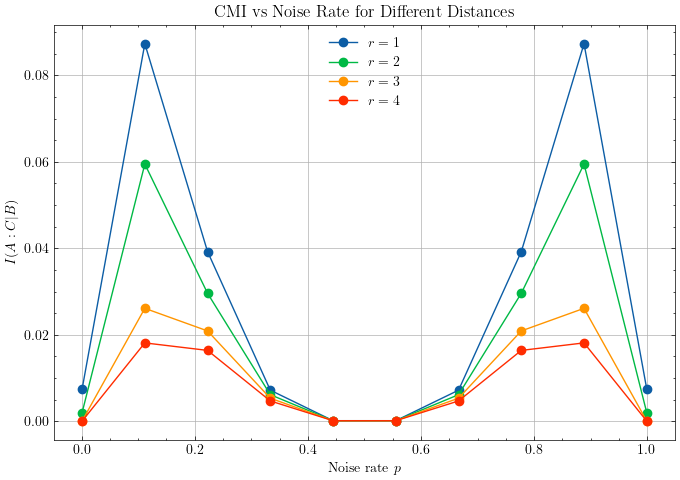

In [34]:
# ============================================================
# CMI vs noise rate p for different distances r
# ============================================================


plt.style.use('science')
plt.figure(figsize=(7,5))

# Choose which distances to display
#selected_distances = [1, 2, 4, 6, 8]

for r in distances:
    plt.plot(p_array2,cmi_matrix[:, r-1],marker='o',label=fr"$r={r}$")

plt.xlabel("Noise rate $p$")
plt.ylabel(r"$I(A:C|B)$")
plt.title("CMI vs Noise Rate for Different Distances")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

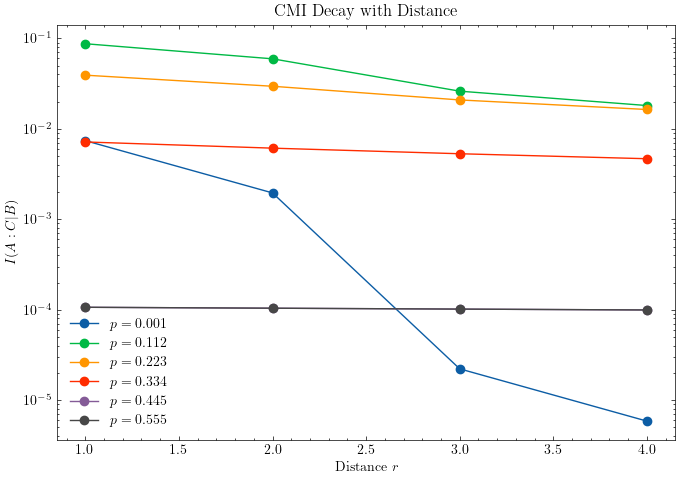

In [33]:
# ============================================================
# CMI vs distance r for different noise rates p
# ============================================================

plt.figure(figsize=(7,5))
plt.style.use('science')

# Choose which p values to display
#selected_p_indices = [0, 5, 10, 15, 20]

for idx in range(6):

    #p = p_array2[idx]

    plt.plot(distances,cmi_matrix[idx],marker='o',label=fr"$p={p_array2[idx]:.3f}$")

plt.yscale('log')

plt.xlabel("Distance $r$")
plt.ylabel(r"$I(A:C|B)$")
plt.title("CMI Decay with Distance")
plt.legend()
#plt.grid(True, which='both')
plt.tight_layout()
plt.show()

In [37]:
def fit_markov_length_offset(distances, cmi_values, offset=1.0, threshold=1e-12):
    """
    Fit:

        CMI(r) - offset = a exp(-r / xi)

    so:

        log(CMI(r) - offset) = log(a) - r / xi
    """

    distances = np.array(distances)
    cmi_values = np.array(cmi_values)

    shifted = cmi_values - offset

    # Only keep points where log is well-defined
    mask = shifted > threshold

    if np.sum(mask) < 2:
        return np.nan

    x = distances[mask]
    y = np.log(shifted[mask])

    slope, intercept = np.polyfit(x, y, 1)

    if slope >= 0:
        return np.nan

    return -1.0 / slope

# ------------------------------------------------------------
# Define distance-dependent partitions
# ------------------------------------------------------------

LA = 2
LC = 2

# ------------------------------------------------------------
# Define maximum system size
# ------------------------------------------------------------
N2 = 10

distances = np.arange(1, N2 - LA - LC + 1)

cmi_matrix = np.zeros((len(p_array2), len(distances)))

for ip, p in enumerate(p_array2):
    for idd, d in enumerate(distances):

        A_d = list(range(0, LA))
        B_d = list(range(LA, LA + d))
        C_d = list(range(LA + d, LA + d + LC))

        cmi_matrix[ip, idd] = CMI(
            p,
            rho_GHZ,
            A=A_d,
            B=B_d,
            C=C_d,
            N=N
        )

    shifted = cmi_matrix[ip] - 1.0
    print(
        f"p={p:.4f}, "
        f"min CMI={np.min(cmi_matrix[ip]):.6e}, "
        f"max CMI={np.max(cmi_matrix[ip]):.6e}, "
        f"positive shifted points={np.sum(shifted > 1e-12)}"
    )
# ------------------------------------------------------------
# Fit Markov length for every p
# ------------------------------------------------------------



xi_array = np.array([
    fit_markov_length_offset(distances, cmi_matrix[ip], offset=1.0)
    for ip in range(len(p_array2))
])

p=0.0010, min CMI=2.310352e-08, max CMI=1.133943e-02, positive shifted points=0
p=0.1119, min CMI=1.420805e-02, max CMI=2.324385e-01, positive shifted points=0


KeyboardInterrupt: 